# 🎓 UC4 - Machine Learning e Data Mining (Analista de Dados)
## 🧪 Aula 05 - Métricas de Avaliação de Modelos de Classificação

Nesta prática guiada, vamos avaliar matematicamente a qualidade dos nossos modelos de classificação preditivos utilizando a base Iris. Analisaremos além da acurácia básica, comparando a Árvore de Decisão e o KNN.

### 🎯 Objetivos:
1. Carregar a base e preparar os modelos: **Árvore de Decisão** (Aula 03) e **KNN** (Aula 04).
2. Gerar a **Matriz de Confusão** e analisar seus erros e acertos.
3. Comparar as métricas de **Acurácia, Precisão, Recall e F1-Score** entre os modelos.
4. Experimentar de forma prática o perigo da Acurácia em uma base simulada desbalanceada.

---
### ⚙️ Passo 0: Carregando e Treinando os Modelos Anteriores

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Carregando o dataset Iris
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30)

# 1. Treinando a Árvore de Decisão (Aula 03 - não exige normalização)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=30).fit(X_train, y_train)

# 2. Treinando o KNN (Aula 04 - exige dados normalizados)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn_model = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)

# Gerando previsões de ambos para a base de teste
y_pred_tree = tree_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test_scaled)

print("Modelos de Árvore e KNN treinados com sucesso!")

Modelos de Árvore e KNN treinados com sucesso!


---
### 📊 Passo 1: Extraindo a Matriz de Confusão
Vamos plotar visualmente a matriz de confusão para ambos os modelos.

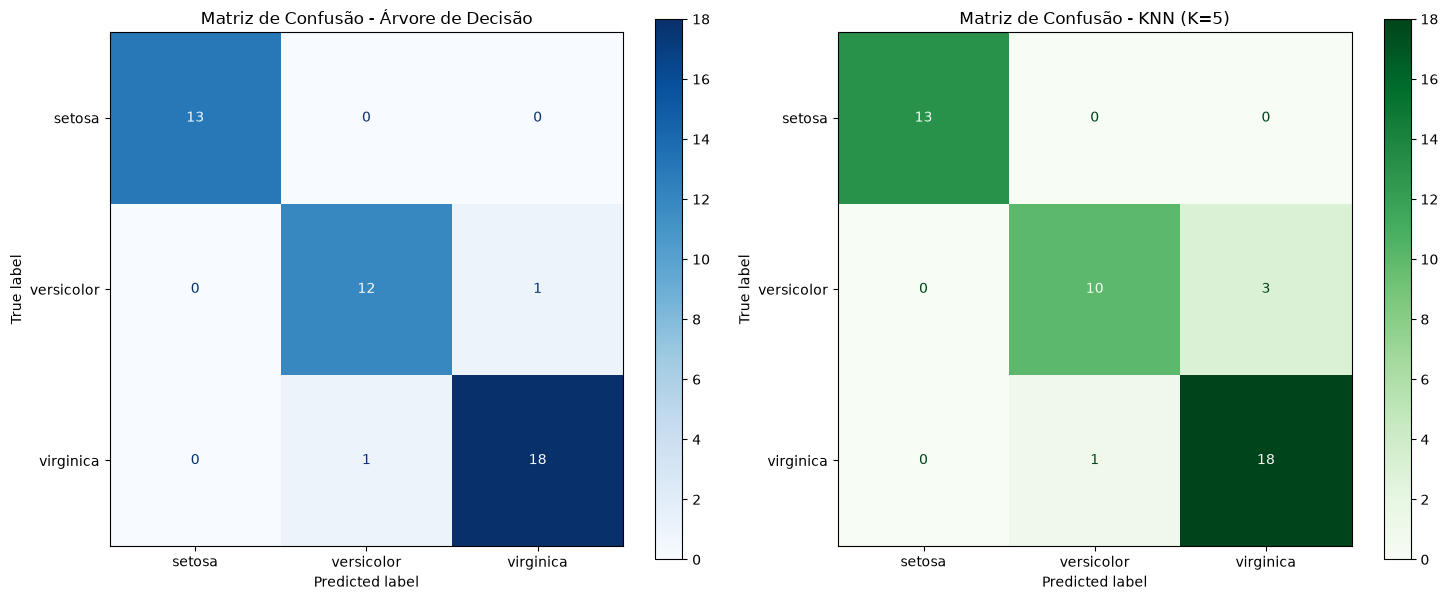

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Matriz da Árvore de Decisão
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=iris.target_names)
disp_tree.plot(cmap=plt.cm.Blues, ax=ax[0])
ax[0].set_title("Matriz de Confusão - Árvore de Decisão")

# Matriz do KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=iris.target_names)
disp_knn.plot(cmap=plt.cm.Greens, ax=ax[1])
ax[1].set_title("Matriz de Confusão - KNN (K=5)")

plt.tight_layout()
plt.show()

---
### 📐 Passo 2: Analisando as Métricas Completas (Classification Report)
Vamos gerar o relatório consolidando a Precisão, Recall e F1-Score por classe.

In [3]:
print("=== RELATÓRIO DE CLASSIFICAÇÃO: ÁRVORE DE DECISÃO ===")
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO: KNN (K=5) ===")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

=== RELATÓRIO DE CLASSIFICAÇÃO: ÁRVORE DE DECISÃO ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.92      0.92      0.92        13
   virginica       0.95      0.95      0.95        19

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45


=== RELATÓRIO DE CLASSIFICAÇÃO: KNN (K=5) ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.91      0.77      0.83        13
   virginica       0.86      0.95      0.90        19

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.91      0.91      0.91        45



### 🧐 Guia Didático: Como Interpretar estes Resultados?

Abaixo está o mapa definitivo para ler a **Matriz de Confusão** e o **Classification Report** sem mistérios:

#### 1. A Matriz de Confusão 3x3 (Iris - random_state=30)
Lembre-se sempre desta regra de ouro:
- **Linhas representam a REALIDADE** (quantas amostras existem de fato em cada classe).
- **Colunas representam as PREVISÕES** (o que o modelo detectou).
- **A Diagonal Principal** (do topo-esquerdo ao inferior-direito) contém os **Acertos**. Os outros campos fora da diagonal são os **Erros**.

```text
                 PREVISTO (Coluna)
               Setosa  Versicolor  Virginica
             ┌──────────────────────────────┐
      Setosa │   13        0           0    │  <- Acertos = 13/13 (100%)
REAL Versicolor │    0       10           3    │  <- 10 acertos | 3 Versicolors confundidas com Virginica
(Linha)Virginica │    0        1          18    │  <- 18 acertos | 1 Virginica confundida com Versicolor
             └──────────────────────────────┘
```

#### 2. Cálculo das Métricas (Exemplo prático para a classe `Versicolor` no KNN)

- **Precisão (Precision) - Qualidade do Alarme:** De tudo o que o modelo disse ser Versicolor (soma da Coluna Versicolor = 10 + 1 = 11), quanto ele acertou?
  $$\text{Precisão (Versicolor)} = \frac{\text{Acertos (VP)}}{\text{Previsões Totais}} = \frac{10}{10 + 1} = \frac{10}{11} \approx 91\%$$
  *(Significa que 91% dos alarmes de Versicolor eram reais; 9% foram alarmes falsos de Virginica)*

- **Sensibilidade (Recall) - Poder de Detecção:** De todas as Versicolors que existiam na realidade (soma da Linha Versicolor = 10 + 3 = 13), quantas o modelo capturou?
  $$\text{Recall (Versicolor)} = \frac{\text{Acertos (VP)}}{\text{Realidade Total}} = \frac{10}{10 + 3} = \frac{10}{13} \approx 77\%$$
  *(Significa que o modelo foi cego para 23% das Versicolors, deixando-as passar como Virginicas)*

- **F1-Score - Equilíbrio:** Média harmônica entre Precisão e Recall. Evita que o modelo passe com nota alta se tiver um Recall péssimo ou uma Precisão horrível.

#### 3. Entendendo os Termos de Rodapé do Relatório
- **Support (Suporte):** A quantidade real de flores daquela espécie na base de teste (Setosa = 13, Versicolor = 13, Virginica = 19).
- **Macro Avg (Média Macro):** Média aritmética simples dos scores das três classes. Trata todas as classes igualmente, sem importar se uma tem mais dados que a outra.
- **Weighted Avg (Média Ponderada):** Média dos scores ponderada pela quantidade de dados (Suporte) de cada classe. Reflete a proporção real dos dados do teste.


---
### 🧩 Passo 3: Discussão de Negócio
Observe o desempenho dos dois modelos por espécie de flor:
- Qual espécie obteve 100% de acerto em ambos os modelos? Por quê?
- Qual modelo obteve melhor performance geral para diferenciar Versicolor e Virginica?
- Por que a espécie Setosa é linearmente tão simples de separar em relação às outras?

*(Escreva suas observações nesta célula)*
- **Espécie 100% correta:** 
- **Modelo superior nas desafiadoras:** 
- **Por que Setosa é simples:** 

---
### 🚨 Desafio Prático: A Armadilha da Acurácia
Vamos criar um cenário fictício altamente desbalanceado: 990 transações normais e apenas 10 fraudes. Analisaremos a acurácia de um classificador que simplesmente chuta "Transação Normal" para todas as previsões.

In [4]:
# y_real simulado: 990 normais (0) e 10 fraudes (1)
y_real_simulado = np.array([0]*990 + [1]*10)

# y_pred_ficticio: chute cego na classe normal (0) para todas as transações
y_pred_ficticio = np.array([0]*1000)

# 1. Acurácia geral
acuracia = accuracy_score(y_real_simulado, y_pred_ficticio)
print(f"Acurácia do modelo que só chuta Normal: {acuracia * 100:.2f}%")

# 2. Classification Report (zero_division=0 evita erros matemáticos por divisão por zero no recall)
print("\nRelatório de Classificação do Modelo Fictício:\n")
print(classification_report(y_real_simulado, y_pred_ficticio, target_names=["Normal", "Fraude"], zero_division=0))

Acurácia do modelo que só chuta Normal: 99.00%

Relatório de Classificação do Modelo Fictício:

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       990
      Fraude       0.00      0.00      0.00        10

    accuracy                           0.99      1000
   macro avg       0.49      0.50      0.50      1000
weighted avg       0.98      0.99      0.99      1000

